# Tutorial 55: Compare Calculations

The Tutorial demonstrates how to execute calculations for the same model in adjusted valve states and view the individual results.

# Imports

## SIR 3S Toolkit

### Regular Import/Init

In [2]:
SIR3S_SIRGRAF_DIR = r"C:\3S\SIR 3S\SirGraf-90-15-00-24_Quebec-Upd2" #change to local path

In [3]:
from sir3stoolkit.core import wrapper

In [4]:
wrapper

<module 'sir3stoolkit.core.wrapper' from 'C:\\Users\\aUsername\\3S\\sir3stoolkit\\src\\sir3stoolkit\\core\\wrapper.py'>

In [5]:
wrapper.Initialize_Toolkit(SIR3S_SIRGRAF_DIR)

### Additional Import/Init for Dataframes class

In [6]:
from sir3stoolkit.mantle.dataframes import SIR3S_Model_Dataframes

In [7]:
s3s = SIR3S_Model_Dataframes()

Initialization complete


## Additional

In [8]:
import matplotlib.pyplot as plt

# Open Model

For the tutorial we have a simple hydraulic setup. A node with 4 t/h net outflow simulates some consumption. It is supplied by two pipes. The one from the left has a boundary pressure of 6 bar and a valve, we will control, the one from the right has a boundary pressure of 3 bar and no valve.

In [9]:
s3s.OpenModel(dbName=r"Toolkit_Tutorial55_Model.db3",
              providerType=s3s.ProviderTypes.SQLite,
              Mid="M-1-0-1",
              saveCurrentlyOpenModel=False,
              namedInstance="",
              userID="",
              password="")

Model is open for further operation


Valves:
- 'bz.Indphi': -1: geschlossen, 0: offen, 1: Tabellenverweis, 2: variabel
- 'bz.Phio': Stellung offen [%]
- 'bz.Phig': Stellung geschlossen [%]
- 'bz.Phisoll': Stellung variabel [%]
- 'bz.Fkphi1',
- 'bz.Tiv',
- 'bz.IndPhiKonst',
- 'bz.IndphiKlartext'

# Get Tk

In [10]:
valve = s3s.GetTksofElementType(s3s.ObjectTypes.Valve)[0]

# 1. Scenario: Valve open (100%)

In [11]:
s3s.SetValue(Tk=valve, propertyName="bz.Indphi", Value="0")

Value is set


In [12]:
s3s.ExecCalculation(True)

Model Calculation is complete


In [13]:
df_nodes_1 = s3s.generate_element_dataframe(s3s.ObjectTypes.Node)

[2026-03-18 13:51:20,968] INFO in sir3stoolkit.mantle.dataframes: [generate_element_dataframe] Generating df for element type: ObjectTypes.Node ...
[2026-03-18 13:51:20,970] DEBUG in sir3stoolkit.mantle.dataframes: [generate_element_dataframe] Generating df_model_data for element type: ObjectTypes.Node ...
[2026-03-18 13:51:21,044] INFO in sir3stoolkit.mantle.dataframes: [model_data] Generating model_data dataframe for element type: ObjectTypes.Node
[2026-03-18 13:51:21,044] INFO in sir3stoolkit.mantle.dataframes: [model_data] Retrieved 4 element(s) of element type ObjectTypes.Node.
[2026-03-18 13:51:21,061] INFO in sir3stoolkit.mantle.dataframes: [Resolving model_data Properties] No properties given → using ALL model_data properties for ObjectTypes.Node.
[2026-03-18 13:51:21,061] INFO in sir3stoolkit.mantle.dataframes: [Resolving model_data Properties] Using 37 model_data properties.
[2026-03-18 13:51:21,061] INFO in sir3stoolkit.mantle.dataframes: [model_data] Retrieving model_data p

In [14]:
df_nodes_1

,tk,Name,Ktyp,Zkor,QmEin,Lfakt,Fkpzon,Fkfstf,Fkutmp,Fkfqps,Fkcont,Fk2lknot,Beschreibung,Idreferenz,Iplanung,Kvr,Qakt,Xkor,Ykor,NodeNamePosition,ShowNodeName,KvrKlartext,NumberOfVERB,HasBlockConnection,Tk,Pk,InVariant,GeometriesDiffer,SymbolFactor,bz.Drakonz,bz.Fk,bz.Fkpvar,bz.Fkqvar,bz.Fklfkt,bz.PhEin,bz.Tm,bz.Te,bz.PhMin,geometry,BCIND,BCIND_CALC,BCIND_FLOW,BCIND_MODEL,BCIND_SOURCE,BCIND_TYPE,CP,DP,DPH,DYNVISKO,ESQUELLSP,FITT_ANGLE,FITT_BASTYPE,FITT_DP1,FITT_DP2,FITT_DP3,FITT_STATE,FITT_SUBTYPE,FITT_VBTYPE1,FITT_VBTYPE2,FITT_VBTYPE3,FITT_ZETA1,FITT_ZETA2,FITT_ZETA3,FSTF_NAME,H,HMAX_INST,HMIN_INST,IAKTIV,LFAKTAKT,LFKT,M,P,PDAMPF,PH,PHMINMAXDIF,PH_EIN,PH_MIN,PMAX_INST,PMIN_INST,PVAR,Q2,QM,QMABS,QVAR,RHO,T,TE,TMAX_INST,TMIN_INST,TTR,VOLD,WALTER,ZHKNR
0,4627226928120134070,NODE02,QKON,0,0,1,-1,5035918757120503777,4966523102239983321,-1,4744960050823542042,-1,Upstream of valve,2,1,1,0,40,0,1,False,Vorlauf,0,False,4627226928120134070,4627226928120134070,False,False,1,0,4627226928120134070,-1,-1,-1,0,0,0,0,POINT Z (40 0 0),17.0,0.0,0.0,16.0,0.0,1.0,4.2074,-3.333333e+32,-3.333333e+32,0.001729,NaN,-3.333333e+32,-333333333.0,-3.333333e+32,-3.333333e+32,-3.333333e+32,-333333333.0,NaN,NaN,NaN,NaN,-3.333333e+32,-3.333333e+32,-3.333333e+32,NaN,3.127404,3.127404,3.127404,0.0,1.0,NaN,0.000000,4.127404,0.0066,3.127404,0.0,3.127404,0.0,4.127404,4.127404,NaN,-3.333333e+32,0.00000,0.00000,NaN,1000.5,0.0,0.0,0.0,0.0,0.000479,0.0,-3.333333e+32,0.0
1,4853856122080314724,NODE03,QKON,0,-4,1,-1,5035918757120503777,4966523102239983321,-1,4744960050823542042,-1,Downstream of valve,3,1,1,-4,80,0,1,False,Vorlauf,0,False,4853856122080314724,4853856122080314724,False,False,1,0,4853856122080314724,-1,-1,-1,0,0,0,0,POINT Z (80 0 0),21.0,0.0,4.0,16.0,0.0,1.0,4.2074,-3.333333e+32,-3.333333e+32,0.001729,NaN,-3.333333e+32,-333333333.0,-3.333333e+32,-3.333333e+32,-3.333333e+32,-333333333.0,NaN,NaN,NaN,NaN,-3.333333e+32,-3.333333e+32,-3.333333e+32,NaN,3.093694,3.093694,3.093694,0.0,1.0,NaN,-1.111111,4.093695,0.0066,3.093694,0.0,3.093694,0.0,4.093695,4.093695,NaN,-3.333333e+32,-4.00000,4.00000,NaN,1000.5,0.0,0.0,0.0,0.0,0.000479,0.0,-3.333333e+32,0.0
2,5631143277892559364,NODE04,PKON,0,-10,1,-1,5035918757120503777,4966523102239983321,-1,4744960050823542042,-1,Template Element for single Node Creation,3S5612430692880892331,1,1,0,120,0,1,False,Vorlauf,0,False,5631143277892559364,5631143277892559364,False,False,1,0,5631143277892559364,-1,-1,-1,2,0,0,0,POINT Z (120 0 0),20.0,0.0,4.0,16.0,0.0,0.0,4.2074,-3.333333e+32,-3.333333e+32,0.001729,NaN,-3.333333e+32,-333333333.0,-3.333333e+32,-3.333333e+32,-3.333333e+32,-333333333.0,NaN,NaN,NaN,NaN,-3.333333e+32,-3.333333e+32,-3.333333e+32,NaN,2.000000,2.000000,2.000000,0.0,1.0,NaN,-3.559523,3.000000,0.0066,2.000000,0.0,2.000000,0.0,3.000000,3.000000,NaN,-3.333333e+32,-12.81428,12.81428,NaN,1000.5,0.0,0.0,0.0,0.0,0.001106,0.0,-3.333333e+32,0.0
3,5698868843196465579,NODE01,PKON,0,0,1,-1,5035918757120503777,4966523102239983321,-1,4744960050823542042,-1,Upstream of valve,1,1,1,0,0,0,1,False,Vorlauf,0,False,5698868843196465579,5698868843196465579,False,False,1,0,5698868843196465579,-1,-1,-1,5,0,0,0,POINT Z (0 0 0),24.0,0.0,8.0,16.0,0.0,0.0,4.2074,-3.333333e+32,-3.333333e+32,0.001729,NaN,-3.333333e+32,-333333333.0,-3.333333e+32,-3.333333e+32,-3.333333e+32,-333333333.0,NaN,NaN,NaN,NaN,-3.333333e+32,-3.333333e+32,-3.333333e+32,NaN,5.000000,5.000000,5.000000,0.0,1.0,NaN,4.670634,6.000000,0.0066,5.000000,0.0,5.000000,0.0,6.000000,6.000000,NaN,-3.333333e+32,16.81428,16.81428,NaN,1000.5,0.0,0.0,0.0,0.0,0.000000,0.0,-3.333333e+32,0.0


# 2. Scenario: Valve closed (0%)

In [15]:
s3s.SetValue(Tk=valve, propertyName="bz.Indphi", Value="-1")

Value is set


In [16]:
s3s.ExecCalculation(True)

Model Calculation is complete


In [17]:
df_nodes_2 = s3s.generate_element_dataframe(s3s.ObjectTypes.Node)

[2026-03-18 13:51:25,597] INFO in sir3stoolkit.mantle.dataframes: [generate_element_dataframe] Generating df for element type: ObjectTypes.Node ...
[2026-03-18 13:51:25,597] DEBUG in sir3stoolkit.mantle.dataframes: [generate_element_dataframe] Generating df_model_data for element type: ObjectTypes.Node ...
[2026-03-18 13:51:25,605] INFO in sir3stoolkit.mantle.dataframes: [model_data] Generating model_data dataframe for element type: ObjectTypes.Node
[2026-03-18 13:51:25,607] INFO in sir3stoolkit.mantle.dataframes: [model_data] Retrieved 4 element(s) of element type ObjectTypes.Node.
[2026-03-18 13:51:25,608] INFO in sir3stoolkit.mantle.dataframes: [Resolving model_data Properties] No properties given → using ALL model_data properties for ObjectTypes.Node.
[2026-03-18 13:51:25,610] INFO in sir3stoolkit.mantle.dataframes: [Resolving model_data Properties] Using 37 model_data properties.
[2026-03-18 13:51:25,610] INFO in sir3stoolkit.mantle.dataframes: [model_data] Retrieving model_data p

In [18]:
df_nodes_2

,tk,Name,Ktyp,Zkor,QmEin,Lfakt,Fkpzon,Fkfstf,Fkutmp,Fkfqps,Fkcont,Fk2lknot,Beschreibung,Idreferenz,Iplanung,Kvr,Qakt,Xkor,Ykor,NodeNamePosition,ShowNodeName,KvrKlartext,NumberOfVERB,HasBlockConnection,Tk,Pk,InVariant,GeometriesDiffer,SymbolFactor,bz.Drakonz,bz.Fk,bz.Fkpvar,bz.Fkqvar,bz.Fklfkt,bz.PhEin,bz.Tm,bz.Te,bz.PhMin,geometry,BCIND,BCIND_CALC,BCIND_FLOW,BCIND_MODEL,BCIND_SOURCE,BCIND_TYPE,CP,DP,DPH,DYNVISKO,ESQUELLSP,FITT_ANGLE,FITT_BASTYPE,FITT_DP1,FITT_DP2,FITT_DP3,FITT_STATE,FITT_SUBTYPE,FITT_VBTYPE1,FITT_VBTYPE2,FITT_VBTYPE3,FITT_ZETA1,FITT_ZETA2,FITT_ZETA3,FSTF_NAME,H,HMAX_INST,HMIN_INST,IAKTIV,LFAKTAKT,LFKT,M,P,PDAMPF,PH,PHMINMAXDIF,PH_EIN,PH_MIN,PMAX_INST,PMIN_INST,PVAR,Q2,QM,QMABS,QVAR,RHO,T,TE,TMAX_INST,TMIN_INST,TTR,VOLD,WALTER,ZHKNR
0,4627226928120134070,NODE02,QKON,0,0,1,-1,5035918757120503777,4966523102239983321,-1,4744960050823542042,-1,Upstream of valve,2,1,1,0,40,0,1,False,Vorlauf,0,False,4627226928120134070,4627226928120134070,False,False,1,0,4627226928120134070,-1,-1,-1,0,0,0,0,POINT Z (40 0 0),17.0,0.0,0.0,16.0,0.0,1.0,4.2074,-3.333333e+32,-3.333333e+32,0.001729,NaN,-3.333333e+32,-333333333.0,-3.333333e+32,-3.333333e+32,-3.333333e+32,-333333333.0,NaN,NaN,NaN,NaN,-3.333333e+32,-3.333333e+32,-3.333333e+32,NaN,4.999999,4.999999,4.999999,0.0,1.0,NaN,0.000000,5.999999,0.0066,4.999999,0.0,4.999999,0.0,5.999999,5.999999,NaN,-3.333333e+32,0.000000,0.000000,NaN,1000.5,0.0,0.0,0.0,0.0,10.000000,0.0,-3.333333e+32,0.0
1,4853856122080314724,NODE03,QKON,0,-4,1,-1,5035918757120503777,4966523102239983321,-1,4744960050823542042,-1,Downstream of valve,3,1,1,-4,80,0,1,False,Vorlauf,0,False,4853856122080314724,4853856122080314724,False,False,1,0,4853856122080314724,-1,-1,-1,0,0,0,0,POINT Z (80 0 0),21.0,0.0,4.0,16.0,0.0,1.0,4.2074,-3.333333e+32,-3.333333e+32,0.001729,NaN,-3.333333e+32,-333333333.0,-3.333333e+32,-3.333333e+32,-3.333333e+32,-333333333.0,NaN,NaN,NaN,NaN,-3.333333e+32,-3.333333e+32,-3.333333e+32,NaN,1.888348,1.888348,1.888348,0.0,1.0,NaN,-1.111111,2.888347,0.0066,1.888348,0.0,1.888348,0.0,2.888347,2.888347,NaN,-3.333333e+32,-4.000000,4.000000,NaN,1000.5,0.0,0.0,0.0,0.0,0.003818,0.0,-3.333333e+32,1.0
2,5631143277892559364,NODE04,PKON,0,-10,1,-1,5035918757120503777,4966523102239983321,-1,4744960050823542042,-1,Template Element for single Node Creation,3S5612430692880892331,1,1,0,120,0,1,False,Vorlauf,0,False,5631143277892559364,5631143277892559364,False,False,1,0,5631143277892559364,-1,-1,-1,2,0,0,0,POINT Z (120 0 0),24.0,0.0,8.0,16.0,0.0,0.0,4.2074,-3.333333e+32,-3.333333e+32,0.001729,NaN,-3.333333e+32,-333333333.0,-3.333333e+32,-3.333333e+32,-3.333333e+32,-333333333.0,NaN,NaN,NaN,NaN,-3.333333e+32,-3.333333e+32,-3.333333e+32,NaN,2.000000,2.000000,2.000000,0.0,1.0,NaN,1.110910,3.000000,0.0066,2.000000,0.0,2.000000,0.0,3.000000,3.000000,NaN,-3.333333e+32,3.999278,3.999278,NaN,1000.5,0.0,0.0,0.0,0.0,0.000000,0.0,-3.333333e+32,1.0
3,5698868843196465579,NODE01,PKON,0,0,1,-1,5035918757120503777,4966523102239983321,-1,4744960050823542042,-1,Upstream of valve,1,1,1,0,0,0,1,False,Vorlauf,0,False,5698868843196465579,5698868843196465579,False,False,1,0,5698868843196465579,-1,-1,-1,5,0,0,0,POINT Z (0 0 0),24.0,0.0,8.0,16.0,0.0,0.0,4.2074,-3.333333e+32,-3.333333e+32,0.001729,NaN,-3.333333e+32,-333333333.0,-3.333333e+32,-3.333333e+32,-3.333333e+32,-333333333.0,NaN,NaN,NaN,NaN,-3.333333e+32,-3.333333e+32,-3.333333e+32,NaN,5.000000,5.000000,5.000000,0.0,1.0,NaN,0.000201,6.000000,0.0066,5.000000,0.0,5.000000,0.0,6.000000,6.000000,NaN,-3.333333e+32,0.000722,0.000722,NaN,1000.5,0.0,0.0,0.0,0.0,0.000000,0.0,-3.333333e+32,0.0


# 3. Scenario: Valve variable (55%)

In [19]:
s3s.SetValue(Tk=valve, propertyName="bz.Indphi", Value="2")

Value is set


In [20]:
s3s.ExecCalculation(True)

Model Calculation is complete


In [21]:
df_nodes_3 = s3s.generate_element_dataframe(s3s.ObjectTypes.Node)

[2026-03-18 13:51:29,715] INFO in sir3stoolkit.mantle.dataframes: [generate_element_dataframe] Generating df for element type: ObjectTypes.Node ...
[2026-03-18 13:51:29,716] DEBUG in sir3stoolkit.mantle.dataframes: [generate_element_dataframe] Generating df_model_data for element type: ObjectTypes.Node ...
[2026-03-18 13:51:29,722] INFO in sir3stoolkit.mantle.dataframes: [model_data] Generating model_data dataframe for element type: ObjectTypes.Node
[2026-03-18 13:51:29,723] INFO in sir3stoolkit.mantle.dataframes: [model_data] Retrieved 4 element(s) of element type ObjectTypes.Node.
[2026-03-18 13:51:29,726] INFO in sir3stoolkit.mantle.dataframes: [Resolving model_data Properties] No properties given → using ALL model_data properties for ObjectTypes.Node.
[2026-03-18 13:51:29,726] INFO in sir3stoolkit.mantle.dataframes: [Resolving model_data Properties] Using 37 model_data properties.
[2026-03-18 13:51:29,726] INFO in sir3stoolkit.mantle.dataframes: [model_data] Retrieving model_data p

In [22]:
df_nodes_3

,tk,Name,Ktyp,Zkor,QmEin,Lfakt,Fkpzon,Fkfstf,Fkutmp,Fkfqps,Fkcont,Fk2lknot,Beschreibung,Idreferenz,Iplanung,Kvr,Qakt,Xkor,Ykor,NodeNamePosition,ShowNodeName,KvrKlartext,NumberOfVERB,HasBlockConnection,Tk,Pk,InVariant,GeometriesDiffer,SymbolFactor,bz.Drakonz,bz.Fk,bz.Fkpvar,bz.Fkqvar,bz.Fklfkt,bz.PhEin,bz.Tm,bz.Te,bz.PhMin,geometry,BCIND,BCIND_CALC,BCIND_FLOW,BCIND_MODEL,BCIND_SOURCE,BCIND_TYPE,CP,DP,DPH,DYNVISKO,ESQUELLSP,FITT_ANGLE,FITT_BASTYPE,FITT_DP1,FITT_DP2,FITT_DP3,FITT_STATE,FITT_SUBTYPE,FITT_VBTYPE1,FITT_VBTYPE2,FITT_VBTYPE3,FITT_ZETA1,FITT_ZETA2,FITT_ZETA3,FSTF_NAME,H,HMAX_INST,HMIN_INST,IAKTIV,LFAKTAKT,LFKT,M,P,PDAMPF,PH,PHMINMAXDIF,PH_EIN,PH_MIN,PMAX_INST,PMIN_INST,PVAR,Q2,QM,QMABS,QVAR,RHO,T,TE,TMAX_INST,TMIN_INST,TTR,VOLD,WALTER,ZHKNR
0,4627226928120134070,NODE02,QKON,0,0,1,-1,5035918757120503777,4966523102239983321,-1,4744960050823542042,-1,Upstream of valve,2,1,1,0,40,0,1,False,Vorlauf,0,False,4627226928120134070,4627226928120134070,False,False,1,0,4627226928120134070,-1,-1,-1,0,0,0,0,POINT Z (40 0 0),17.0,0.0,0.0,16.0,0.0,1.0,4.2074,-3.333333e+32,-3.333333e+32,0.001729,NaN,-3.333333e+32,-333333333.0,-3.333333e+32,-3.333333e+32,-3.333333e+32,-333333333.0,NaN,NaN,NaN,NaN,-3.333333e+32,-3.333333e+32,-3.333333e+32,NaN,3.239119,3.239119,3.239119,0.0,1.0,NaN,0.000000,4.239119,0.0066,3.239119,0.0,3.239119,0.0,4.239119,4.239119,NaN,-3.333333e+32,0.00000,0.00000,NaN,1000.5,0.0,0.0,0.0,0.0,0.000494,0.0,-3.333333e+32,0.0
1,4853856122080314724,NODE03,QKON,0,-4,1,-1,5035918757120503777,4966523102239983321,-1,4744960050823542042,-1,Downstream of valve,3,1,1,-4,80,0,1,False,Vorlauf,0,False,4853856122080314724,4853856122080314724,False,False,1,0,4853856122080314724,-1,-1,-1,0,0,0,0,POINT Z (80 0 0),21.0,0.0,4.0,16.0,0.0,1.0,4.2074,-3.333333e+32,-3.333333e+32,0.001729,NaN,-3.333333e+32,-333333333.0,-3.333333e+32,-3.333333e+32,-3.333333e+32,-333333333.0,NaN,NaN,NaN,NaN,-3.333333e+32,-3.333333e+32,-3.333333e+32,NaN,3.008708,3.008708,3.008708,0.0,1.0,NaN,-1.111111,4.008708,0.0066,3.008708,0.0,3.008708,0.0,4.008708,4.008708,NaN,-3.333333e+32,-4.00000,4.00000,NaN,1000.5,0.0,0.0,0.0,0.0,0.000494,0.0,-3.333333e+32,0.0
2,5631143277892559364,NODE04,PKON,0,-10,1,-1,5035918757120503777,4966523102239983321,-1,4744960050823542042,-1,Template Element for single Node Creation,3S5612430692880892331,1,1,0,120,0,1,False,Vorlauf,0,False,5631143277892559364,5631143277892559364,False,False,1,0,5631143277892559364,-1,-1,-1,2,0,0,0,POINT Z (120 0 0),20.0,0.0,4.0,16.0,0.0,0.0,4.2074,-3.333333e+32,-3.333333e+32,0.001729,NaN,-3.333333e+32,-333333333.0,-3.333333e+32,-3.333333e+32,-3.333333e+32,-333333333.0,NaN,NaN,NaN,NaN,-3.333333e+32,-3.333333e+32,-3.333333e+32,NaN,2.000000,2.000000,2.000000,0.0,1.0,NaN,-3.416775,3.000000,0.0066,2.000000,0.0,2.000000,0.0,3.000000,3.000000,NaN,-3.333333e+32,-12.30039,12.30039,NaN,1000.5,0.0,0.0,0.0,0.0,0.001148,0.0,-3.333333e+32,0.0
3,5698868843196465579,NODE01,PKON,0,0,1,-1,5035918757120503777,4966523102239983321,-1,4744960050823542042,-1,Upstream of valve,1,1,1,0,0,0,1,False,Vorlauf,0,False,5698868843196465579,5698868843196465579,False,False,1,0,5698868843196465579,-1,-1,-1,5,0,0,0,POINT Z (0 0 0),24.0,0.0,8.0,16.0,0.0,0.0,4.2074,-3.333333e+32,-3.333333e+32,0.001729,NaN,-3.333333e+32,-333333333.0,-3.333333e+32,-3.333333e+32,-3.333333e+32,-333333333.0,NaN,NaN,NaN,NaN,-3.333333e+32,-3.333333e+32,-3.333333e+32,NaN,5.000000,5.000000,5.000000,0.0,1.0,NaN,4.527887,6.000000,0.0066,5.000000,0.0,5.000000,0.0,6.000000,6.000000,NaN,-3.333333e+32,16.30039,16.30039,NaN,1000.5,0.0,0.0,0.0,0.0,0.000000,0.0,-3.333333e+32,0.0


# Pressure Comparison

In [23]:
def plot_geometry_pressure(df, valve_percentage, geom_col="geometry", p_col="P"):
    """
    Scatter plot of geometry points colored by P.
    Adds numeric pressure labels and ONE centered text box.
    """

    xs = [pt.x for pt in df[geom_col]]
    ys = [pt.y for pt in df[geom_col]]
    P = df[p_col]

    plt.figure(figsize=(6, 5))
    sc = plt.scatter(xs, ys, c=P, cmap="viridis", s=50)

    for x, y, p in zip(xs, ys, P):
        plt.annotate(
            f"{p:.2f}",
            xy=(x, y),
            xytext=(5, 5),               # Offset: 5 px right, 5 px up
            textcoords="offset points",
            fontsize=8,
            ha="left",
            va="bottom"
        )

    # colorbar = legend
    cbar = plt.colorbar(sc)
    cbar.set_label(p_col)

    plt.xlabel("x")
    plt.ylabel("y")
    plt.axis('off')
    plt.title(f"Node Pressure Visualization — Valve {valve_percentage}%")

    # very rudimentary just for tutorial
    plt.text(
        0.5, 0.5,
        f"- Pipe -               - Valve -               - Pipe - ",
        transform=plt.gca().transAxes,   # use axes coordinates
        fontsize=12,
        color="black",
        ha="center",
        va="center",
    )

    plt.tight_layout()
    plt.show()

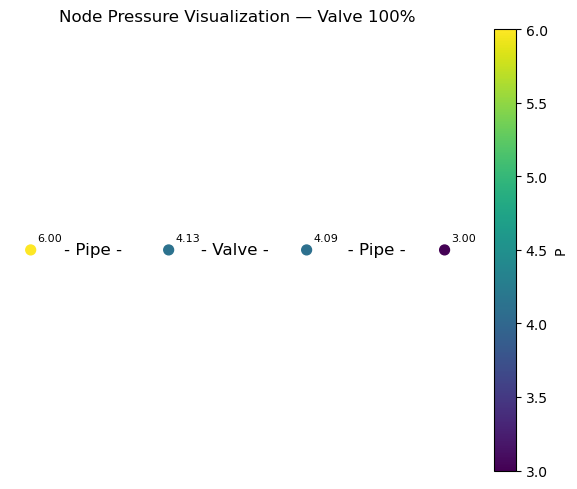

In [24]:
plot_geometry_pressure(df=df_nodes_1, valve_percentage="100")

Note that due to the simplicitiy of the model we consider, we will actually have some net outflow on the right most node.

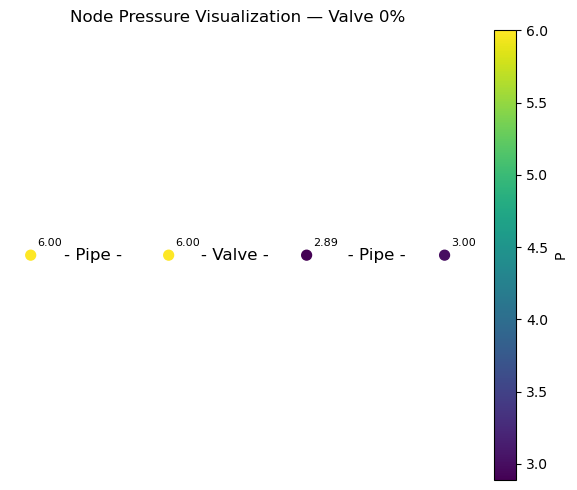

In [25]:
plot_geometry_pressure(df=df_nodes_2, valve_percentage="0")

Now the left and right part are completley decoupled as the valve is shut.

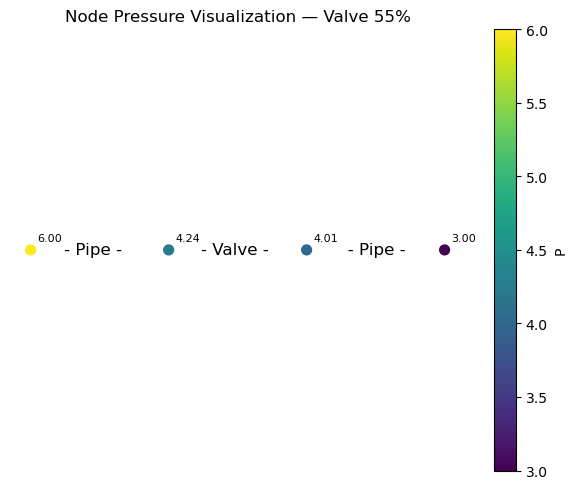

In [26]:
plot_geometry_pressure(df=df_nodes_3, valve_percentage="55")

We can observe a large pressure drop across the valve than at 100 % opening.

In [27]:
s3s.CloseModel(False)

True